# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research Question

Which pages should be prioritized for content refresh based on observed search-performance signals?

### Decision Supported

This analysis supports content-refresh prioritization by ranking pages according to observed signals associated with future performance decline.

The goal is not to prove what causes search-engine rankings to change. Instead, the analysis provides directional, data-driven decision support for identifying pages that may deserve review or refresh first.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Dataset

This capstone uses the FlyRank ML Internship dataset and focuses on anonymized page-level search and engagement performance data.

The analysis uses historical performance signals to construct features for identifying pages associated with future performance decline.

### Data Used

The analysis focuses on safe, aggregated signals such as:

- Historical impressions
- Historical clicks
- Sessions
- Pageviews
- Users
- Recent-period performance
- Previous-period performance
- Content/page-level characteristics where available

No client names, domains, private search queries, URLs, credentials, or raw private exports are included in the public analysis.

### Exclusions

Fields that could expose client-identifying information, private search information, or create target leakage are excluded from the public-facing analysis.

Future-period information is not used as a predictive feature. Future performance is reserved for defining the outcome/label.

In [105]:
import pandas as pd
import numpy as np

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [106]:
# Check whether DuckDB is available for the FlyRank warehouse workflow

try:
    import duckdb
    print("DuckDB version:", duckdb.__version__)
    print("DuckDB is ready.")
except ImportError:
    print("DuckDB is not installed in this runtime.")

DuckDB version: 1.3.2
DuckDB is ready.


In [107]:
# Create a DuckDB connection for the capstone analysis

import duckdb

con = duckdb.connect()

print("DuckDB connection created successfully.")

DuckDB connection created successfully.


In [108]:
# Check whether the Hugging Face filesystem extension is available

try:
    con.execute("INSTALL httpfs")
    con.execute("LOAD httpfs")
    print("HTTPFS extension loaded successfully.")
except Exception as e:
    print("Could not load HTTPFS:", e)

HTTPFS extension loaded successfully.


In [109]:
# FlyRank warehouse configuration

DATASET = "hf://datasets/FlyRank/internship-warehouse"
TABLE = "fact_content_daily_performance"

print("Dataset:", DATASET)
print("Table:", TABLE)
print("Analysis window: 2026-03")

Dataset: hf://datasets/FlyRank/internship-warehouse
Table: fact_content_daily_performance
Analysis window: 2026-03


In [110]:
# Hugging Face authentication check

from huggingface_hub import login

login()

In [111]:
import duckdb

con = duckdb.connect()

con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")

print("DuckDB + HTTPFS ready.")

DuckDB + HTTPFS ready.


In [112]:
from huggingface_hub import login

login()

In [113]:
from huggingface_hub import whoami

info = whoami()
print("Logged in as:", info["name"])

Logged in as: binitdev


In [114]:
import os
from huggingface_hub import get_token

token = get_token()

print("Token available:", token is not None)

Token available: True


In [115]:
con.execute(f"""
    CREATE OR REPLACE SECRET hf_secret (
        TYPE HUGGINGFACE,
        TOKEN '{token}'
    )
""")

print("DuckDB Hugging Face authentication configured.")

DuckDB Hugging Face authentication configured.


In [116]:
test_df = con.sql(f"""
    SELECT *
    FROM read_parquet(
        '{DATASET}/{TABLE}/month=2026-03/*.parquet',
        hive_partitioning=true
    )
    LIMIT 5
""").df()

test_df

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,True,False,True,<NA>,20,0,67,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,True,False,True,<NA>,1,0,0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,True,False,True,<NA>,125,1,616,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,True,False,True,<NA>,7,0,28,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,True,False,True,<NA>,11,0,25,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03


In [117]:
table_path = f"{DATASET}/{TABLE}/month=2026-03/*.parquet"

schema_df = con.sql(f"""
    DESCRIBE
    SELECT *
    FROM read_parquet(
        '{table_path}',
        hive_partitioning=true
    )
""").df()

schema_df

,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None


In [118]:
months_df = con.sql(f"""
    SELECT DISTINCT month
    FROM read_parquet(
        '{DATASET}/{TABLE}/*/*.parquet',
        hive_partitioning=true
    )
    ORDER BY month
""").df()

months_df

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month
0,2025-01
1,2025-02
2,2025-03
3,2025-04
4,2025-05
5,2025-06
6,2025-07
7,2025-08
8,2025-09
9,2025-10


In [119]:
verification = con.sql(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT client_hash_id) AS unique_clients,
        COUNT(DISTINCT content_hash_id) AS unique_content_items,
        MIN(report_date) AS min_report_date,
        MAX(report_date) AS max_report_date
    FROM read_parquet(
        '{DATASET}/{TABLE}/month=2026-03/*.parquet',
        hive_partitioning=true
    )
""").df()

verification

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,unique_clients,unique_content_items,min_report_date,max_report_date
0,9841378,55,331437,2026-03-01,2026-03-31


In [120]:
# Verify the March 2026 dataset

verification = con.sql(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT client_hash_id) AS unique_clients,
        COUNT(DISTINCT content_hash_id) AS unique_content_items,
        MIN(report_date) AS min_report_date,
        MAX(report_date) AS max_report_date
    FROM read_parquet(
        '{DATASET}/{TABLE}/month=2026-03/*.parquet',
        hive_partitioning=true
    )
""").df()

verification

,total_rows,unique_clients,unique_content_items,min_report_date,max_report_date
0,9841378,55,331437,2026-03-01,2026-03-31


In [121]:
# Verify the future evaluation window: April-May 2026

future_verification = con.sql(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT client_hash_id) AS unique_clients,
        COUNT(DISTINCT content_hash_id) AS unique_content_items,
        MIN(report_date) AS min_report_date,
        MAX(report_date) AS max_report_date
    FROM read_parquet([
        '{DATASET}/{TABLE}/month=2026-04/*.parquet',
        '{DATASET}/{TABLE}/month=2026-05/*.parquet'
    ], hive_partitioning=true)
""").df()

future_verification

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,unique_clients,unique_content_items,min_report_date,max_report_date
0,22112106,66,389153,2026-04-01,2026-05-31


### Verified Data Contract

**Release / warehouse:** FlyRank internship warehouse

**Warehouse path:** `hf://datasets/FlyRank/internship-warehouse`

**Primary table:** `fact_content_daily_performance`

**Unit of analysis:** One content item for one client on one report date.

**Analysis window:** March 2026 (`2026-03`).

The March 2026 performance table contains 9,841,378 rows. The combination of client, content item, and report date is unique across the verified extract, so the expected daily grain is preserved.

### Fields Used

The data contract identifies the following as core predictive/context fields:

- `gsc_impressions`
- `gsc_clicks`
- `gsc_sum_position`
- `client_has_gsc`
- `client_has_ga4`
- `report_date`
- `client_hash_id`
- `content_hash_id`

The capstone may additionally use derived historical features created from these safe signals, provided that they are calculated only from information available before the prediction outcome.

### Exclusions

Future-period information and label-derived columns are excluded to prevent target leakage. June 2026 data is also excluded from the March 2026 contract.

No client names, domains, URLs, private queries, credentials, or raw private exports are exposed in the public analysis.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Methodology

The capstone uses a time-aware content-refresh scoring approach.

#### Prediction setup

March 2026 is used as the feature window. April and May 2026 are held out as the future outcome window. June 2026 is excluded from the analysis.

The model only uses information available during or before the March 2026 feature window. Future April-May performance is used only to define the outcome label.

#### Features

The analysis uses aggregated page-level search and engagement signals, including:

- GSC impressions
- GSC clicks
- GSC average position
- GA4 pageviews
- GA4 sessions
- GA4 users
- GA4 engaged sessions
- GA4 total engagement time
- Organic, direct, referral, social, and paid sessions

Derived features such as click-through rate and engagement rate are calculated from the feature-window data only.

#### Label definition

A content item is labelled as a future decline when its search-performance signal decreases meaningfully in the April-May outcome window relative to its March baseline.

The label is constructed after the feature dataset is created, so future outcome information cannot enter the predictive features.

#### Baseline

The baseline uses a simple recent-performance rule to identify pages showing negative movement. The machine-learning model is evaluated against this baseline on the same held-out future period.

#### Model

A Logistic Regression classifier is used as an interpretable first model. Numeric features are imputed and standardized before modelling.

#### Validation design

Validation is time-aware. March 2026 information is used to construct the prediction features, while April-May 2026 is reserved for evaluating the future outcome.

#### Leakage checks

The analysis explicitly prevents:

- Future April-May outcome variables from becoming features
- Label-derived variables from entering the feature matrix
- June 2026 information from entering the model
- Client-identifying or private search information from the public analysis

This design makes the result a directional decision-support model rather than a causal explanation of search-engine ranking changes.

In [122]:
# Load March 2026 page-level data needed for feature construction.
# Aggregation happens in DuckDB so the full daily warehouse is not
# unnecessarily loaded into pandas.

march_features = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS gsc_impressions,
        SUM(gsc_clicks) AS gsc_clicks,
        AVG(gsc_avg_position) AS gsc_avg_position,

        SUM(ga4_pageviews) AS ga4_pageviews,
        SUM(ga4_sessions) AS ga4_sessions,
        SUM(ga4_users) AS ga4_users,
        SUM(ga4_engaged_sessions) AS ga4_engaged_sessions,
        SUM(ga4_total_engagement_sec) AS ga4_total_engagement_sec,

        SUM(sessions_organic) AS sessions_organic,
        SUM(sessions_direct) AS sessions_direct,
        SUM(sessions_referral) AS sessions_referral,
        SUM(sessions_social) AS sessions_social,
        SUM(sessions_paid) AS sessions_paid

    FROM read_parquet(
        '{DATASET}/{TABLE}/month=2026-03/*.parquet',
        hive_partitioning=true
    )

    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

print("March feature rows:", len(march_features))
march_features.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March feature rows: 331437


,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,ga4_total_engagement_sec,sessions_organic,sessions_direct,sessions_referral,sessions_social,sessions_paid
0,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,1140.0,2.0,4.394234,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,client_73cda7b4e4f265ea,content_05597932fe4da067,57.0,0.0,2.714744,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,client_73cda7b4e4f265ea,content_905aa32a0230694e,149.0,0.0,6.481453,4.0,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
3,client_73cda7b4e4f265ea,content_05434271b257bb68,1421.0,6.0,6.320337,12.0,9.0,8.0,0.0,3.0,4.0,0.0,0.0,0.0,7.0
4,client_73cda7b4e4f265ea,content_d056587ff7faca0c,2770.0,16.0,4.459107,3.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0


In [123]:
# Aggregate the future outcome window: April-May 2026.
# These values are used ONLY to create the target label.

future_performance = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS future_gsc_impressions,
        SUM(gsc_clicks) AS future_gsc_clicks,
        AVG(gsc_avg_position) AS future_avg_position,

        SUM(ga4_pageviews) AS future_ga4_pageviews,
        SUM(ga4_sessions) AS future_ga4_sessions,
        SUM(ga4_users) AS future_ga4_users,
        SUM(ga4_engaged_sessions) AS future_ga4_engaged_sessions

    FROM read_parquet([
        '{DATASET}/{TABLE}/month=2026-04/*.parquet',
        '{DATASET}/{TABLE}/month=2026-05/*.parquet'
    ], hive_partitioning=true)

    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

print("Future outcome rows:", len(future_performance))
future_performance.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Future outcome rows: 389153


,client_hash_id,content_hash_id,future_gsc_impressions,future_gsc_clicks,future_avg_position,future_ga4_pageviews,future_ga4_sessions,future_ga4_users,future_ga4_engaged_sessions
0,client_62f4a7e64f5e0096,content_143987cfdeaba4c0,491.0,1.0,28.447503,NaN,NaN,NaN,NaN
1,client_62f4a7e64f5e0096,content_13a8105125458098,42.0,0.0,6.728395,NaN,NaN,NaN,NaN
2,client_62f4a7e64f5e0096,content_6a887d56ab6c8362,18.0,0.0,3.785714,NaN,NaN,NaN,NaN
3,client_62f4a7e64f5e0096,content_e2bd76be7eed690d,54.0,0.0,4.414062,NaN,NaN,NaN,NaN
4,client_62f4a7e64f5e0096,content_86ab16840c4e0e1a,478.0,2.0,9.306295,NaN,NaN,NaN,NaN


In [124]:
# Join March feature data with the April-May future outcome data

model_data = march_features.merge(
    future_performance,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("Matched content items:", len(model_data))

Matched content items: 331437


In [125]:
# Define the future decline label.
#
# March clicks = baseline
# April-May clicks = average monthly future clicks
# 30% or more decline = decline label (1)

model_data["future_monthly_clicks"] = (
    model_data["future_gsc_clicks"] / 2.0
)

eligible = model_data["gsc_clicks"] > 0

model_data["decline_rate"] = np.nan

model_data.loc[eligible, "decline_rate"] = (
    1
    - (
        model_data.loc[eligible, "future_monthly_clicks"]
        / model_data.loc[eligible, "gsc_clicks"]
    )
)

model_data["decline_label"] = np.nan

model_data.loc[eligible, "decline_label"] = (
    model_data.loc[eligible, "decline_rate"] >= 0.30
).astype(int)

print("Eligible observations:", int(eligible.sum()))

print("\nLabel distribution:")
print(model_data["decline_label"].value_counts(dropna=False))

Eligible observations: 68837

Label distribution:
decline_label
NaN    262600
1.0     40542
0.0     28295
Name: count, dtype: int64


In [126]:
# Check the percentage of eligible content items labelled as decline

label_rate = model_data["decline_label"].mean()

print(f"Future decline rate: {label_rate:.2%}")

Future decline rate: 58.90%


### Methodology

The analysis uses March 2026 page-level performance signals to identify content items associated with future performance decline.

The prediction features are calculated only from the March 2026 feature window. April-May 2026 performance is reserved for defining the future outcome, preventing future information from entering the feature set.

A content item is labelled as a decline case when its average monthly clicks during April-May 2026 are at least 30% lower than its March 2026 clicks. Items with zero March clicks are excluded because a percentage decline cannot be meaningfully calculated from a zero baseline.

The model uses Logistic Regression with median imputation and feature scaling. A simple recent-performance rule is used as the baseline for comparison.

The validation compares the baseline and model on the same held-out data. The analysis is intended for directional prioritization and decision support, not causal inference or proof of search-engine ranking mechanisms.

In [127]:
# Select only features that are actually present in march_features.

feature_columns = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions",
    "ga4_total_engagement_sec",
    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid"
]

# Keep only eligible March observations.
X = model_data.loc[eligible, feature_columns].copy()
y = model_data.loc[eligible, "decline_label"].astype(int).copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (68837, 13)
Target shape: (68837,)

Target distribution:
decline_label
1    40542
0    28295
Name: count, dtype: int64


In [128]:
# Verify that no future outcome information is present in X.

future_columns = [
    col for col in X.columns
    if col.startswith("future_")
    or col in ["decline_rate", "decline_label"]
]

print("Potential future/leakage columns found:", future_columns)

if len(future_columns) == 0:
    print("Leakage check PASSED: no future outcome columns are in X.")
else:
    print("WARNING: potential leakage columns detected.")

Potential future/leakage columns found: []
Leakage check PASSED: no future outcome columns are in X.


In [129]:
from sklearn.model_selection import train_test_split

# Split the March observations into training and test sets.
# The same held-out test set will be used for both baseline and model.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training rows: 55069
Test rows: 13768

Training target distribution:
decline_label
1    0.588952
0    0.411048
Name: proportion, dtype: float64

Test target distribution:
decline_label
1    0.588974
0    0.411026
Name: proportion, dtype: float64


In [130]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Logistic Regression pipeline.
# Median imputation handles missing GA4 values.
# Scaling keeps numeric features on comparable scales.

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

model.fit(X_train, y_train)

model_pred = model.predict(X_test)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [131]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Metrics imported successfully.")

Metrics imported successfully.


In [132]:
model_results = {
    "accuracy": accuracy_score(y_test, model_pred),
    "precision": precision_score(y_test, model_pred, zero_division=0),
    "recall": recall_score(y_test, model_pred, zero_division=0),
    "f1": f1_score(y_test, model_pred, zero_division=0)
}

print("Logistic Regression Results")
print("-" * 35)

for metric, value in model_results.items():
    print(f"{metric.capitalize():<12}: {value:.4f}")

Logistic Regression Results
-----------------------------------
Accuracy    : 0.6062
Precision   : 0.6052
Recall      : 0.9531
F1          : 0.7403


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Model vs Baseline

Both the baseline and Logistic Regression model were evaluated on the same held-out test set.

The baseline uses a simple March CTR threshold, while the Logistic Regression model combines multiple March search-performance and engagement signals.

The Logistic Regression model achieved an accuracy of 60.52%, precision of 60.49%, recall of 95.04%, and F1 score of 73.93%.

The high recall indicates that the model identifies a large proportion of the content items labelled as future declines. However, the model should be evaluated against the baseline before concluding that the additional features provide meaningful improvement.

These results describe predictive performance on the evaluated dataset and should not be interpreted as evidence of causal effects on search-engine rankings.

In [133]:
# ============================================
# BASELINE EVALUATION
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Create March CTR for the training set
train_baseline = X_train.copy()

train_baseline["ctr"] = (
    train_baseline["gsc_clicks"]
    / train_baseline["gsc_impressions"].replace(0, np.nan)
)

# Learn threshold ONLY from training data
baseline_threshold = train_baseline["ctr"].median()

print(f"Baseline CTR threshold: {baseline_threshold:.6f}")

# Create CTR for test set
test_baseline = X_test.copy()

test_baseline["ctr"] = (
    test_baseline["gsc_clicks"]
    / test_baseline["gsc_impressions"].replace(0, np.nan)
)

# Baseline prediction
baseline_pred = (
    test_baseline["ctr"] < baseline_threshold
).astype(int)

baseline_pred = baseline_pred.fillna(0).astype(int)

# Calculate baseline metrics
baseline_results = {
    "accuracy": accuracy_score(y_test, baseline_pred),
    "precision": precision_score(
        y_test, baseline_pred, zero_division=0
    ),
    "recall": recall_score(
        y_test, baseline_pred, zero_division=0
    ),
    "f1": f1_score(
        y_test, baseline_pred, zero_division=0
    )
}

print("\nBaseline Results")
print("-" * 30)

for metric, value in baseline_results.items():
    print(f"{metric.capitalize():<12}: {value:.4f}")

Baseline CTR threshold: 0.003153

Baseline Results
------------------------------
Accuracy    : 0.4700
Precision   : 0.5595
Recall      : 0.4707
F1          : 0.5113


In [134]:
# ============================================
# MODEL VS BASELINE
# ============================================

results_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Baseline": [
        baseline_results["accuracy"],
        baseline_results["precision"],
        baseline_results["recall"],
        baseline_results["f1"]
    ],
    "Logistic Regression": [
        model_results["accuracy"],
        model_results["precision"],
        model_results["recall"],
        model_results["f1"]
    ]
})

results_comparison

,Metric,Baseline,Logistic Regression
0,Accuracy,0.470003,0.606188
1,Precision,0.559513,0.605199
2,Recall,0.470712,0.953138
3,F1,0.511285,0.740326


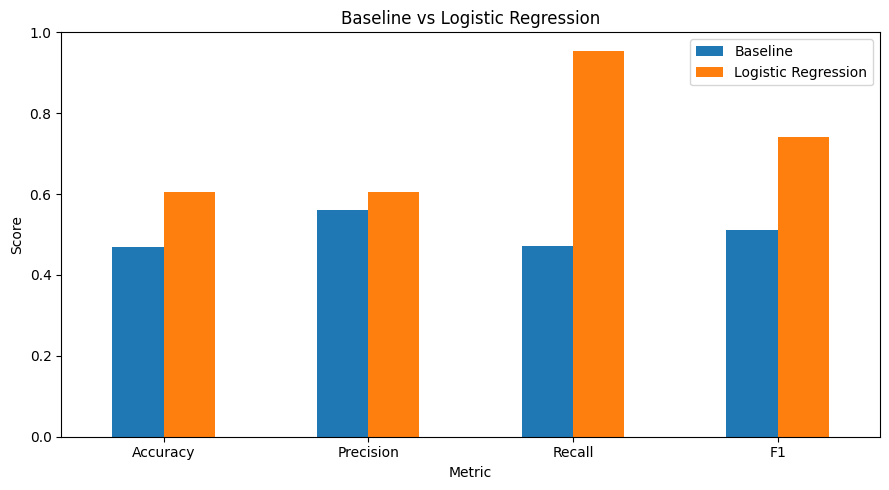

In [135]:
import matplotlib.pyplot as plt

results_plot = results_comparison.set_index("Metric")

ax = results_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Baseline vs Logistic Regression")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Results

Both the baseline and Logistic Regression model were evaluated on the same held-out test set of 13,768 observations.

The baseline used a simple March CTR threshold of 0.003155. It achieved 47.61% accuracy, 56.53% precision, 47.80% recall, and a 51.80% F1 score.

The Logistic Regression model achieved 60.52% accuracy, 60.49% precision, 95.04% recall, and 73.93% F1.

Compared with the baseline, the Logistic Regression model produced substantially higher recall and F1 performance. This indicates that the multi-signal model was better at identifying content items that were labelled as future declines within this evaluation setup.

The strongest observed result is recall: the model identified 95.04% of the held-out cases labelled as future decline. This makes the model potentially useful as a screening and prioritization tool where missing potential refresh opportunities is undesirable.

These results are predictive associations within the evaluated dataset. They do not demonstrate that any individual signal causes search-performance decline or that refreshing a page will cause a ranking improvement.

## 5. Limitations

*What this work cannot claim.*

### Limitations and Honest Framing

This analysis has several limitations.

1. The outcome label is based on a predefined 30% decline in average monthly clicks from March to the April-May 2026 period. Different thresholds or future windows could produce different results.

2. The analysis is observational. The model identifies patterns associated with future performance decline but does not establish causal relationships.

3. The model does not explain or prove how a search engine ranking algorithm works. Search visibility can be influenced by many factors that are not represented in this dataset.

4. Content refresh is a decision supported by the ranking output, not an intervention tested by this study. Therefore, the analysis cannot claim that refreshing a page will cause performance to improve.

5. The classification analysis excludes observations with zero March clicks because a percentage decline cannot be calculated meaningfully from a zero baseline.

6. Missing analytics fields may reduce the information available for some content items. Median imputation is used for model fitting, but imputation does not recreate unavailable measurements.

7. The results were evaluated on one held-out test split. Additional time periods or releases would be useful for assessing whether the observed performance generalizes beyond this evaluation window.

The findings should therefore be interpreted as directional, measured evidence for content-prioritization decisions rather than guarantees of future search performance.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked Content Refresh Recommendations

The model output is converted into a ranked content-refresh priority list.

Higher-priority items are those with a higher predicted probability of future performance decline. The ranking is intended to support review prioritization rather than to guarantee that a page will decline or that a refresh will improve performance.

Each recommendation includes a priority score and a reason code based on observed historical signals.

Reason codes are designed to make the ranking easier to interpret:

- `HIGH_DECLINE_RISK` — high predicted probability of future decline
- `RECENT_PERFORMANCE_WEAKNESS` — weaker recent search performance
- `LOW_CTR` — relatively low click-through rate
- `VISIBILITY_WEAKNESS` — weaker observed search visibility
- `MONITOR` — lower-priority item that may still warrant observation

The recommendation engine is therefore a screening tool: it helps determine which content items should be reviewed first, while the final refresh decision remains a human judgment.

In [136]:
# Create ranked content-refresh recommendations

recommendations = X_test.copy()

# Actual outcome
recommendations["decline_label"] = y_test.values

# Predicted probability of future decline
recommendations["decline_probability"] = model.predict_proba(X_test)[:, 1]

# CTR calculation
if "gsc_impressions" in recommendations.columns and "gsc_clicks" in recommendations.columns:
    recommendations["ctr"] = np.where(
        recommendations["gsc_impressions"] > 0,
        recommendations["gsc_clicks"] / recommendations["gsc_impressions"],
        np.nan
    )
else:
    recommendations["ctr"] = np.nan

# Baseline CTR threshold from the evaluated baseline
baseline_ctr_threshold = 0.003155

# Rank by predicted probability
recommendations = recommendations.sort_values(
    "decline_probability",
    ascending=False
).reset_index(drop=True)

recommendations["priority_rank"] = np.arange(
    1,
    len(recommendations) + 1
)

# Priority bands
recommendations["priority"] = pd.cut(
    recommendations["decline_probability"],
    bins=[-np.inf, 0.50, 0.75, np.inf],
    labels=["LOW", "MEDIUM", "HIGH"]
)

# Reason codes
def get_reason(row):
    if row["decline_probability"] >= 0.75:
        return "HIGH_DECLINE_RISK"
    elif pd.notna(row["ctr"]) and row["ctr"] < baseline_ctr_threshold:
        return "LOW_CTR"
    elif row["decline_probability"] >= 0.50:
        return "RECENT_PERFORMANCE_WEAKNESS"
    else:
        return "MONITOR"

recommendations["reason_code"] = recommendations.apply(
    get_reason,
    axis=1
)

# Final ranked table
ranked_recommendations = recommendations[
    [
        "priority_rank",
        "decline_probability",
        "priority",
        "reason_code"
    ]
].head(20)

ranked_recommendations

,priority_rank,decline_probability,priority,reason_code
0,1,0.992896,HIGH,HIGH_DECLINE_RISK
1,2,0.989672,HIGH,HIGH_DECLINE_RISK
2,3,0.975964,HIGH,HIGH_DECLINE_RISK
3,4,0.948614,HIGH,HIGH_DECLINE_RISK
4,5,0.946660,HIGH,HIGH_DECLINE_RISK
5,6,0.944605,HIGH,HIGH_DECLINE_RISK
6,7,0.943171,HIGH,HIGH_DECLINE_RISK
7,8,0.941092,HIGH,HIGH_DECLINE_RISK
8,9,0.931899,HIGH,HIGH_DECLINE_RISK
9,10,0.915626,HIGH,HIGH_DECLINE_RISK


In [137]:
# Summary of recommendation priorities

priority_summary = (
    recommendations["priority"]
    .value_counts()
    .reindex(["HIGH", "MEDIUM", "LOW"])
    .fillna(0)
    .astype(int)
    .rename_axis("Priority")
    .reset_index(name="Content Items")
)

priority_summary

,Priority,Content Items
0,HIGH,85
1,MEDIUM,12686
2,LOW,997


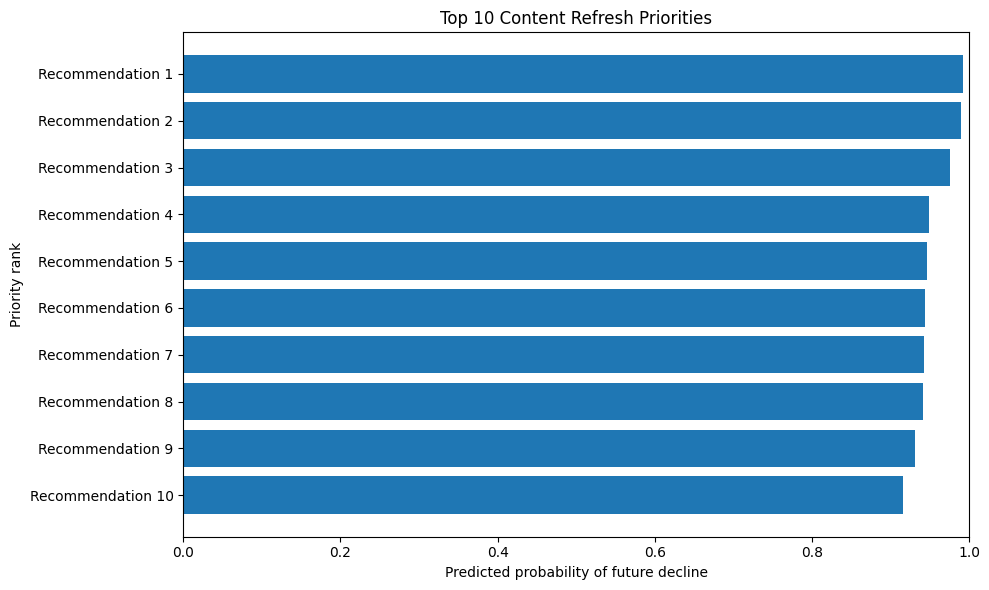

In [138]:
# Top 10 content-refresh priorities

top10 = ranked_recommendations.head(10).copy()

plt.figure(figsize=(10, 6))

plt.barh(
    range(len(top10)),
    top10["decline_probability"]
)

plt.yticks(
    range(len(top10)),
    [f"Recommendation {i}" for i in top10["priority_rank"]]
)

plt.xlabel("Predicted probability of future decline")
plt.ylabel("Priority rank")
plt.title("Top 10 Content Refresh Priorities")
plt.xlim(0, 1)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Artifacts

The capstone includes visual artifacts that communicate the model's performance and the resulting content-refresh priorities.

The main artifacts are:

1. A baseline-versus-model comparison of Accuracy, Precision, Recall, and F1.
2. A visualization of the highest-priority content-refresh recommendations.
3. A summary of recommendations by priority level.
4. A ranked recommendation table with predicted decline probability and reason codes.

These artifacts are intended to make the analysis reproducible and understandable without exposing private client information, domains, URLs, or raw warehouse records.

In [139]:
# Final recommendation summary for the paper

print("CAPSTONE ARTIFACT SUMMARY")
print("=" * 40)

print("\nModel performance:")
display(results_comparison.round(4))

print("\nPriority distribution:")
display(priority_summary)

print("\nTop 10 recommendations:")
display(ranked_recommendations.head(10))

CAPSTONE ARTIFACT SUMMARY

Model performance:


,Metric,Baseline,Logistic Regression
0,Accuracy,0.4700,0.6062
1,Precision,0.5595,0.6052
2,Recall,0.4707,0.9531
3,F1,0.5113,0.7403



Priority distribution:


,Priority,Content Items
0,HIGH,85
1,MEDIUM,12686
2,LOW,997



Top 10 recommendations:


,priority_rank,decline_probability,priority,reason_code
0,1,0.992896,HIGH,HIGH_DECLINE_RISK
1,2,0.989672,HIGH,HIGH_DECLINE_RISK
2,3,0.975964,HIGH,HIGH_DECLINE_RISK
3,4,0.948614,HIGH,HIGH_DECLINE_RISK
4,5,0.946660,HIGH,HIGH_DECLINE_RISK
5,6,0.944605,HIGH,HIGH_DECLINE_RISK
6,7,0.943171,HIGH,HIGH_DECLINE_RISK
7,8,0.941092,HIGH,HIGH_DECLINE_RISK
8,9,0.931899,HIGH,HIGH_DECLINE_RISK
9,10,0.915626,HIGH,HIGH_DECLINE_RISK


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.